In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram

windows = True if os.name == 'nt' else False

if windows:
    workspace_path = "P:/workspaces/lg-ukbiobank/projects/"
else:
    workspace_path = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/"

colors = [ '#ED6B06',  "whitesmoke", '#00786A']
palette = LinearSegmentedColormap.from_list("custom_palette", colors)

labels_g1 = "G1 LIFG IC1,G1 LIFG IC2,G1 LIFG IC3,G1 LSTS IC1,G1 LSTS IC2,G1 LSTS IC3".split(",")
labels_g2 = "G2 LIFG IC1,G2 LIFG IC2,G2 LIFG IC3,G2 LSTS IC1,G2 LSTS IC2,G2 LSTS IC3".split(",")
labels = labels_g1 + labels_g2

In [2]:
def get_cc_data(fn, idx_nms, col_nms):
    data = np.loadtxt(fn)[:, 2]
    data = data.reshape(6,6)
    df = pd.DataFrame(data, columns=col_nms, index=idx_nms)
    return df

def plot_correlation_with_clustering(corr_df, ):
    linkage_matrix = linkage(corr_df, method='average', metric='correlation')
    leaf_order = leaves_list(linkage_matrix)
    corr_df = corr_df.iloc[leaf_order, :].iloc[:, leaf_order]

    # Create figure with subplots for dendrogram and heatmap
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), gridspec_kw={'height_ratios': [1, 10]})
    dendro = dendrogram(linkage_matrix, labels=corr_df.index, leaf_rotation=90, ax=ax1)
    #ax1.set_title("Spatial Correlations between PMAP Components", fontsize=14, fontweight='bold')
    ax1.set_ylabel("")
    #make ticks invisble
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.spines['top'].set_visible(False)      # Remove top border
    ax1.spines['right'].set_visible(False)    # Remove right border
    ax1.spines['bottom'].set_visible(False)   # Remove bottom border
    ax1.spines['left'].set_visible(False)      # Remove left border

    # remove white space between dendrogram and heatmap
    plt.subplots_adjust(hspace=-0.55)

    # Create heatmap subplot
    ax2 = plt.subplot(2, 1, 2)
    sns.heatmap(corr_df.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
                cbar_kws={'label': 'Correlation Coefficient'}, ax=ax2, cbar=False,
                square=True, linewidths=0.5)

    ax2.set_xlabel("Components", fontsize=12)
    ax2.set_ylabel("Components", fontsize=12)
    ax2.set_xticklabels(corr_df.index, rotation=45, size=10, ha='right')
    ax2.set_yticklabels(corr_df.columns, rotation=0, size=10, ha='right')
    ax2.tick_params(axis='both', which='both', length=0)
    
    plt.tight_layout()


C:\Users\jitame\AppData\Local\Temp\ipykernel_14356\3732090006.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_correlation_with_clustering(all_df.fillna(0))


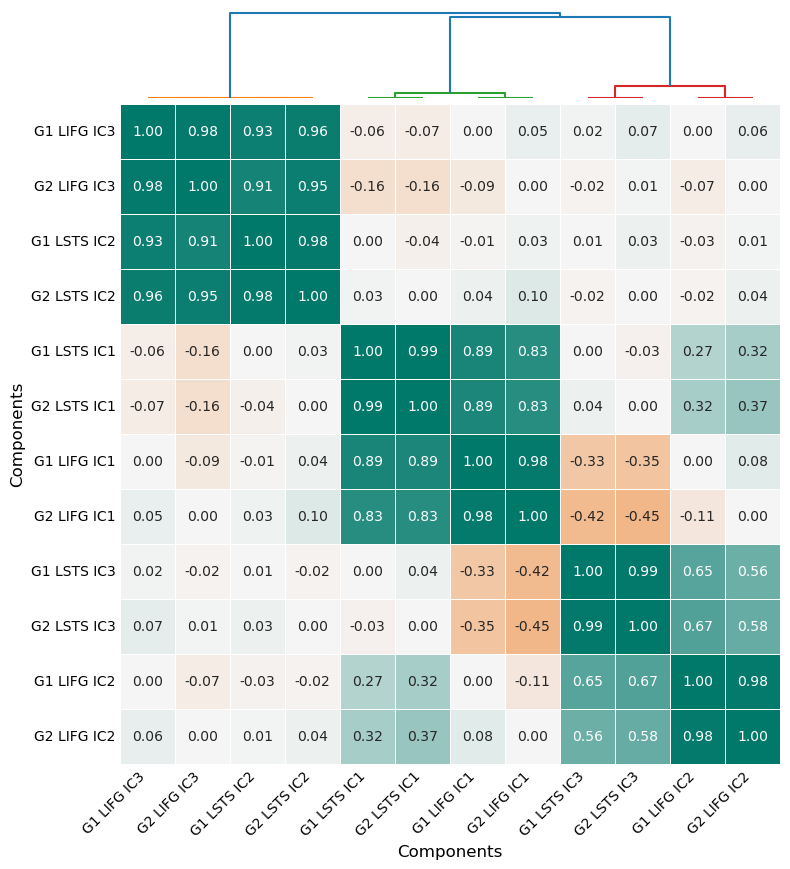

In [3]:
# read spatial correlations from FSLCC
g1_df = get_cc_data(os.path.join(workspace_path, "CONGRADS_rest", "fslcc_g1_pmap.txt"), labels_g1, labels_g1)
g2_df = get_cc_data(os.path.join(workspace_path, "CONGRADS_rest", "fslcc_g2_pmap.txt"), labels_g2, labels_g2)
g1g2_df = get_cc_data(os.path.join(workspace_path, "CONGRADS_rest", "fslcc_g1_g2_pmap.txt"), labels_g1, labels_g2)

all_df = pd.DataFrame(columns=labels_g1 + labels_g2, index=labels_g1 + labels_g2)

for i in all_df.index:
    for j in all_df.columns:
        if i in g1_df.index and j in g1_df.columns:
            all_df.loc[i, j] = g1_df.loc[i, j]
            all_df.loc[j, i] = g1_df.loc[i, j]
        elif i in g2_df.index and j in g2_df.columns:
            all_df.loc[i, j] = g2_df.loc[i, j]
            all_df.loc[j, i] = g2_df.loc[i, j]
        elif i in g1g2_df.index and j in g1g2_df.columns:
            all_df.loc[i, j] = g1g2_df.loc[i, j]
            all_df.loc[j, i] = g1g2_df.loc[i, j]
        elif j in g1g2_df.index and i in g1g2_df.columns:
            all_df.loc[i, j] = g1g2_df.loc[j, i]
            all_df.loc[j, i] = g1g2_df.loc[j, i]
        else:
            all_df.loc[i, j] = np.nan

plot_correlation_with_clustering(all_df.fillna(0))

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "spatial_correlations_clustering.png"), dpi=300)

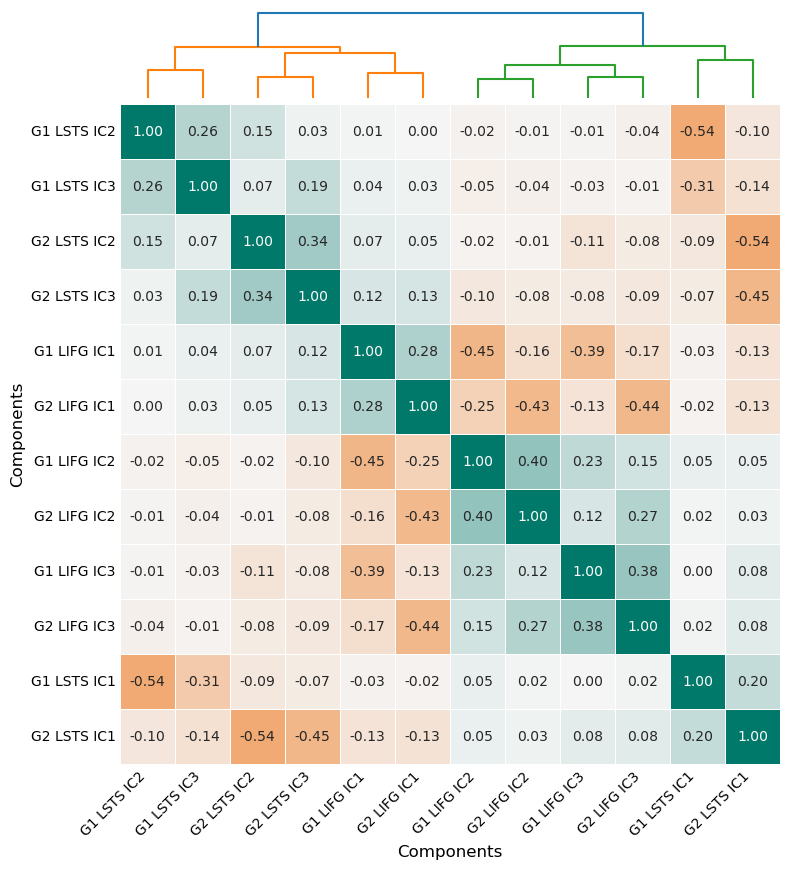

In [4]:
#generate subject loading correlations fromp IDPs
data = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "all_idps_congrads_new_resid_N46267.tsv") , sep="\t")
cols = ["melodic_g1_pmap_lifg_oic_0", "melodic_g1_pmap_lifg_oic_1", "melodic_g1_pmap_lifg_oic_2", "melodic_g1_pmap_lstg_oic_0", "melodic_g1_pmap_lstg_oic_1", "melodic_g1_pmap_lstg_oic_2", "melodic_g2_pmap_lifg_oic_0", "melodic_g2_pmap_lifg_oic_1", "melodic_g2_pmap_lifg_oic_2", "melodic_g2_pmap_lstg_oic_0", "melodic_g2_pmap_lstg_oic_1", "melodic_g2_pmap_lstg_oic_2"]
data = data[cols]
subj_corrs = data.corr()

subj_corrs.columns = labels
subj_corrs.index = labels

plot_correlation_with_clustering(subj_corrs.fillna(0))

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "subject_correlations_clustering.png"), dpi=300)


C:\Users\jitame\AppData\Local\Temp\ipykernel_14356\3885403046.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='white', linewidth=2, edgecolor='black'))


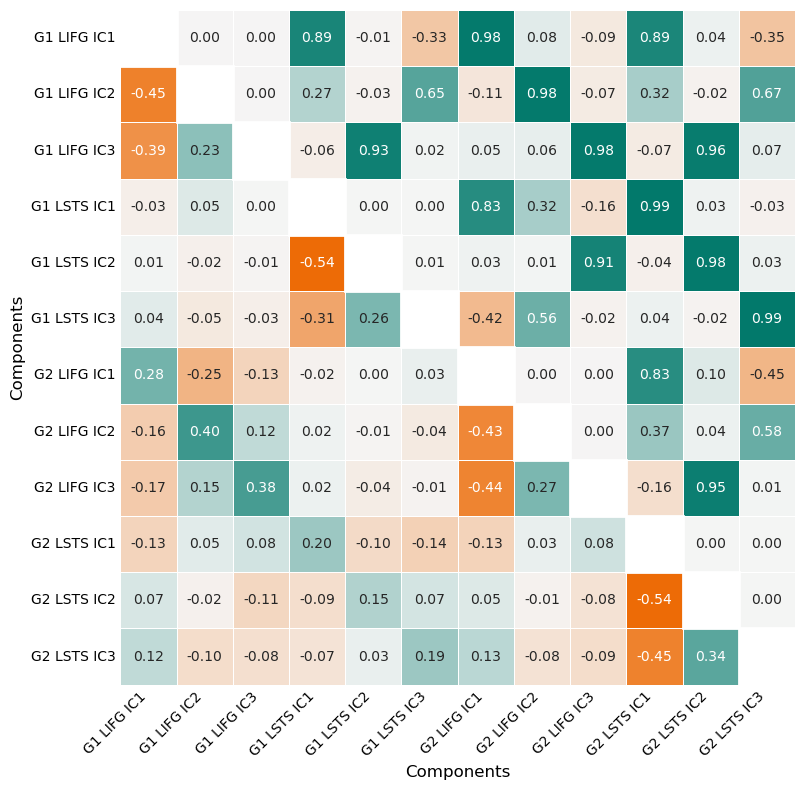

<Figure size 640x480 with 0 Axes>

In [5]:
# generate correlation plot with upper triangle spatial correlations and lower triangle subject loadings correlations
fig, ax = plt.subplots(figsize=(10,8))
#mask to get upper triangle
mask_upper = np.triu(np.ones_like(all_df, dtype=bool), k=1)  # Changed k=0 to k=1 to exclude diagonal
#mask to get lower triangle
mask_lower = np.tril(np.ones_like(subj_corrs, dtype=bool), k=-1)  # Changed k=0 to k=-1 to exclude diagonal

# Plot upper triangle with spatial correlations
sns.heatmap(all_df.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
            cbar_kws={'label': 'Spatial Correlation Coefficient'}, ax=ax, vmin=-1., mask=~mask_upper,
            square=True, linewidths=0.5, cbar=False)

# Plot lower triangle with subject correlations
sns.heatmap(subj_corrs.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
            ax=ax, mask=~mask_lower, cbar=False, square=True, linewidths=0.5)

#make boundaries of the upper triangle mask bold

# Create wider diagonal separation by adding white rectangles with thicker borders
for i in range(len(all_df)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='white', linewidth=2, edgecolor='black'))

ax.set_xlabel("Components", fontsize=12)
ax.set_ylabel("Components", fontsize=12)
ax.set_xticklabels(all_df.index, rotation=45, size=10, ha='right')
ax.set_yticklabels(all_df.columns, rotation=0, size=10, ha='right')
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.show()

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "spatial_subject_correlation_matrix.png"), dpi=300)


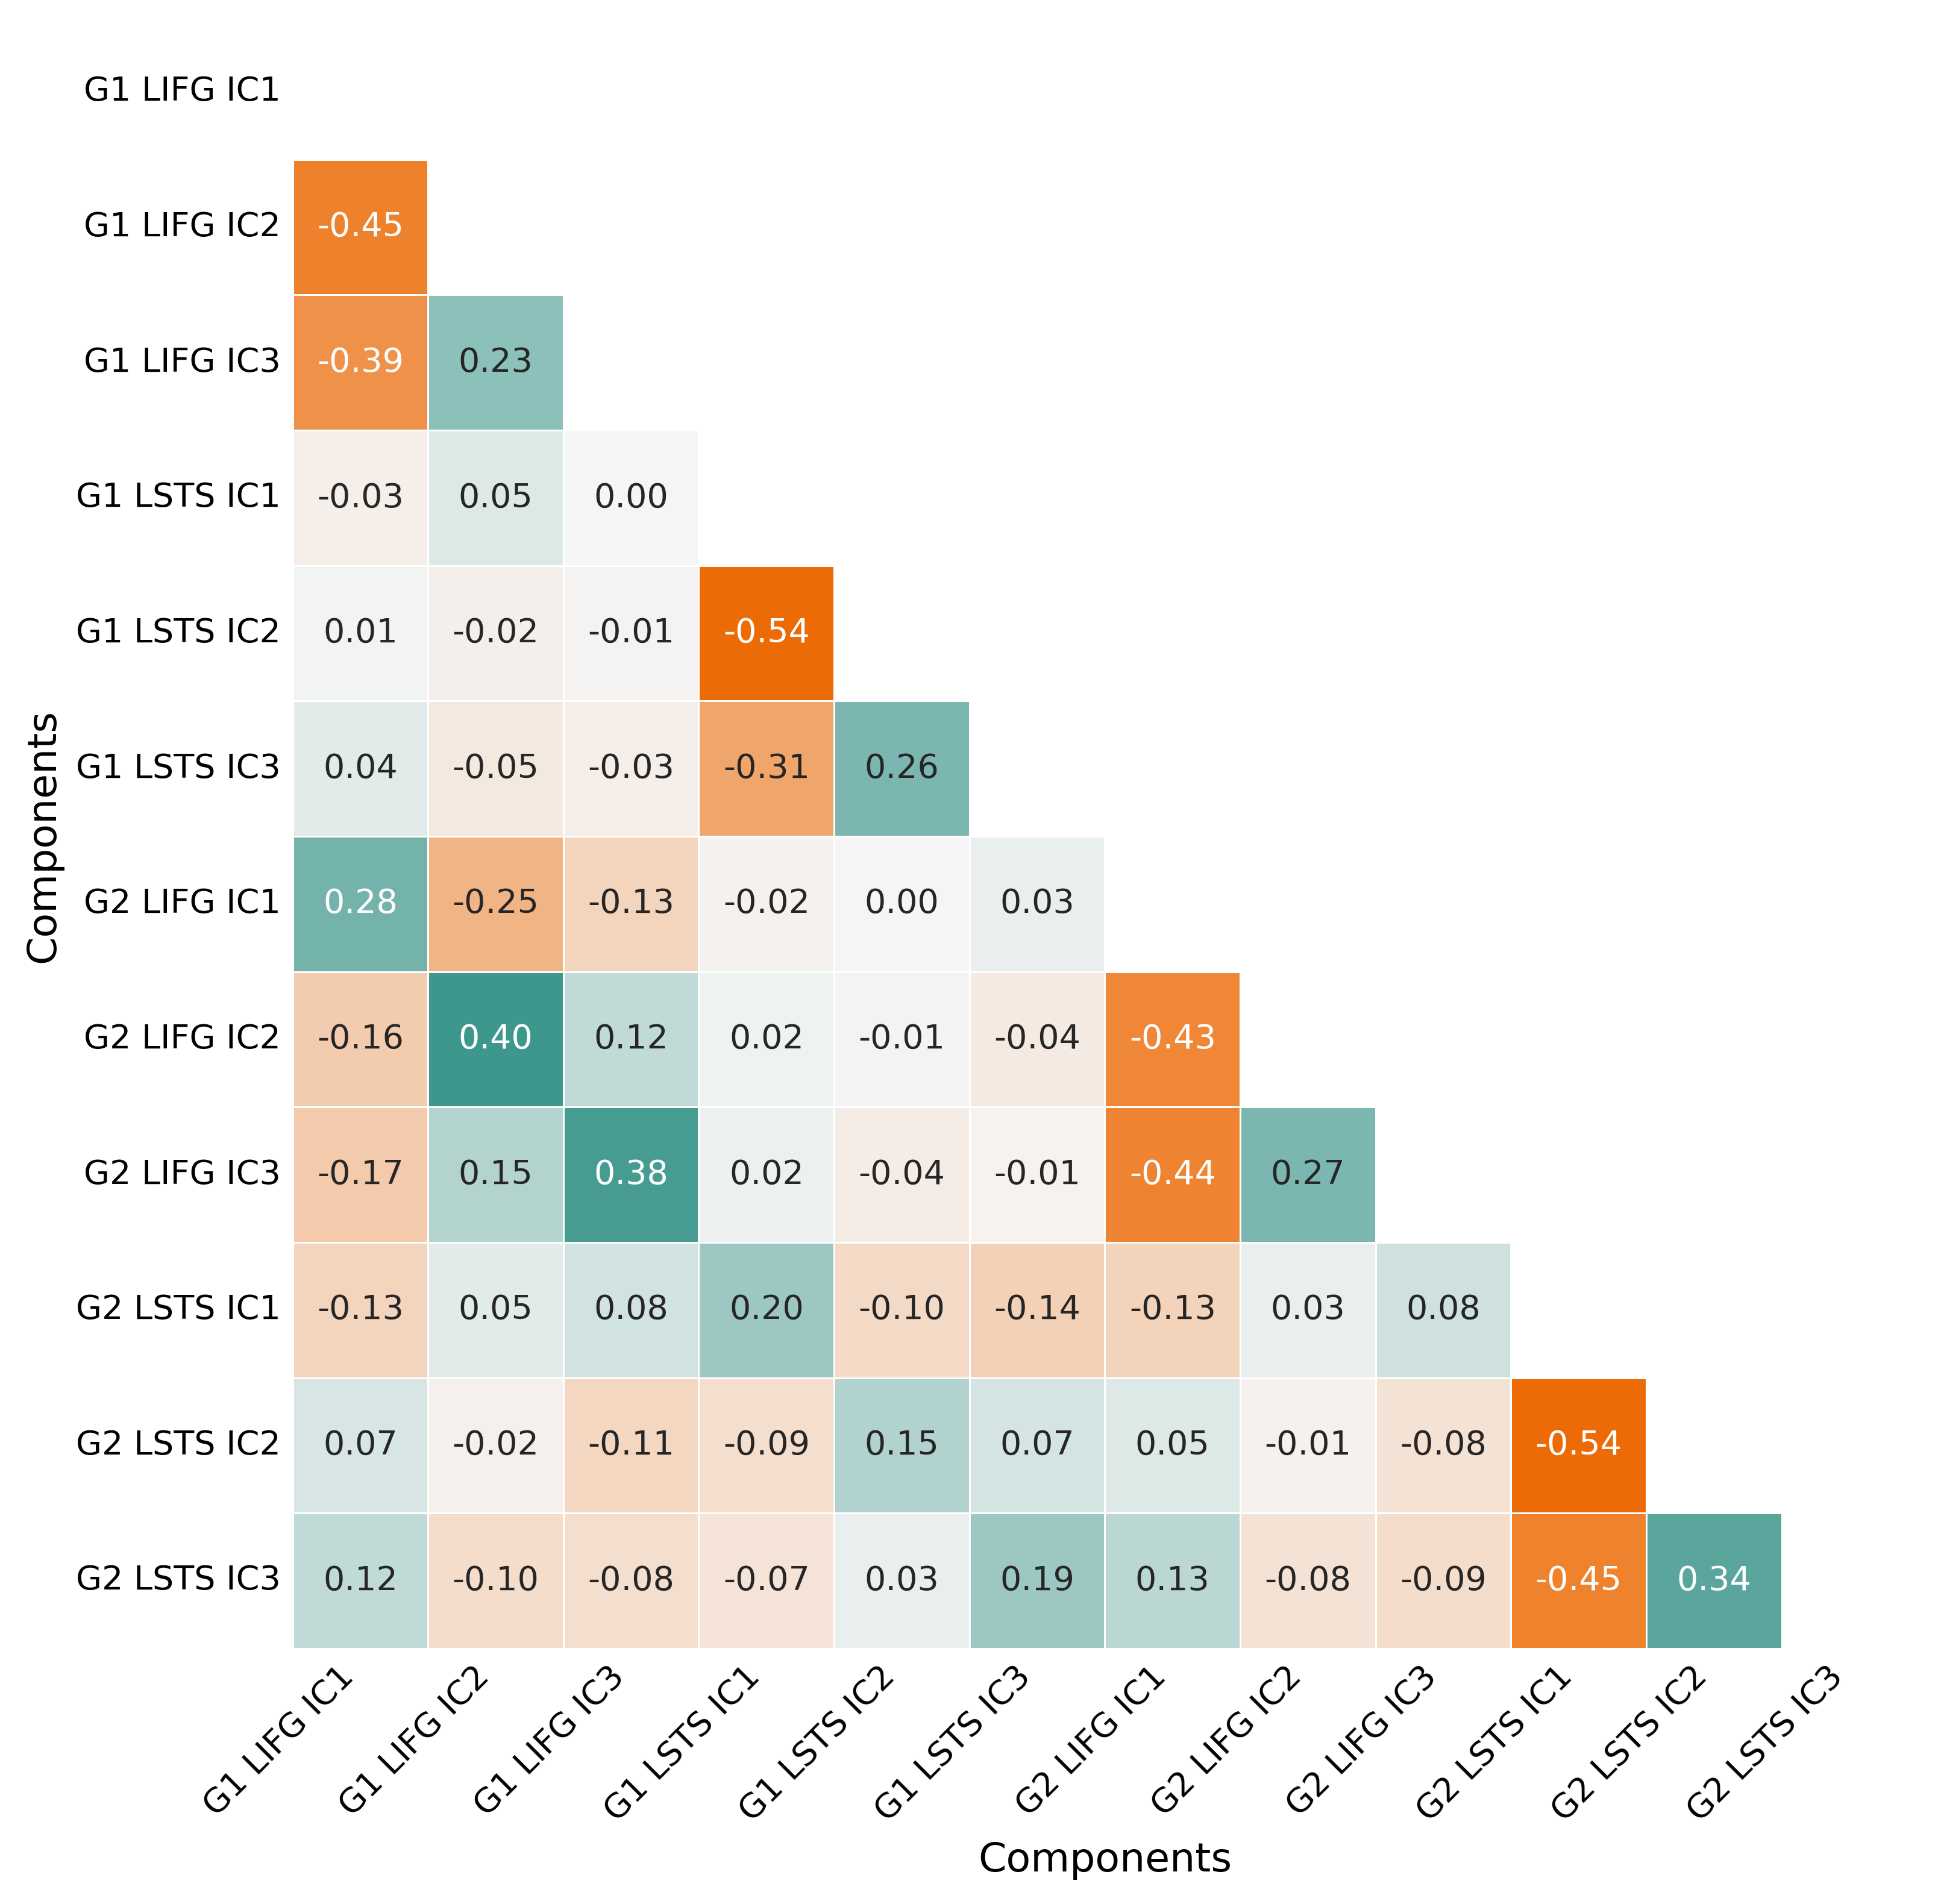

In [6]:
# generate correlation plot with upper triangle spatial correlations and lower triangle subject loadings correlations
fig, ax = plt.subplots(figsize=(10, 8), dpi=400)
#mask to get upper triangle
mask_upper = np.triu(np.ones_like(all_df, dtype=bool), k=1)  # Changed k=0 to k=1 to exclude diagonal
#mask to get lower triangle
mask_lower = np.tril(np.ones_like(subj_corrs, dtype=bool), k=-1)  # Changed k=0 to k=-1 to exclude diagonal



# Plot lower triangle with subject correlations
sns.heatmap(subj_corrs.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
            ax=ax, mask=~mask_lower, cbar=False, square=True, linewidths=0.5)


ax.set_xlabel("Components", fontsize=12)
ax.set_ylabel("Components", fontsize=12)
ax.set_xticklabels(all_df.index, rotation=45, size=10, ha='right')
ax.set_yticklabels(all_df.columns, rotation=0, size=10, ha='right')
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "spatial_subject_correlation_matrix_lower.png"), dpi=400)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=400)

# Plot upper triangle with spatial correlations
sns.heatmap(all_df.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
            cbar_kws={'label': 'Spatial Correlation Coefficient'}, ax=ax, mask=~mask_upper,
            square=True, linewidths=0.5, cbar=False)

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "spatial_subject_correlation_matrix_upper.png"), dpi=400)